# Prédiction du score d'addiction aux réseaux sociaux
## Modèles de Machine Learning (comparaison et analyse) 

**Dataset :** Students Social Media Addiction  
**Variable cible :** `Addicted_Score` — score d'addiction de 2 à 9  
**Type de problème :** Régression  
**Modèle principal :** Random Forest Regressor  

Ce notebook applique plusieurs algorithmes de régression pour prédire le score d'addiction aux réseaux sociaux d'un étudiant à partir de ses caractéristiques personnelles : âge, genre, niveau académique, heures d'utilisation quotidienne, plateforme principale, score de santé mentale, etc.

La méthode de validation est identique pour tous les modèles : séparation 80% entraînement / 20% test avec `random_state=42`, et validation croisée à 5 blocs.

## 1. Importation des bibliothèques

On importe les bibliothèques nécessaires : `pandas` et `numpy` pour la manipulation des données, `matplotlib` et `seaborn` pour les visualisations, et `scikit-learn` pour tous les algorithmes de Machine Learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, BaggingRegressor,
    AdaBoostRegressor, GradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



## 2. Chargement des données et aperçu

On charge le fichier CSV et on examine rapidement sa structure : nombre de lignes, distribution de la variable cible, types de variables et éventuelles valeurs manquantes.

In [60]:
df = pd.read_csv('BDD_initial/Students Social Media Addiction.csv')

print(df.shape)
print(df['Addicted_Score'].describe())
df.head()

(705, 13)
count    705.000000
mean       6.436879
std        1.587165
min        2.000000
25%        5.000000
50%        7.000000
75%        8.000000
max        9.000000
Name: Addicted_Score, dtype: float64


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [61]:
print('Types de données')
print(df.dtypes)
print('\nValeurs manquantes')
print(df.isnull().sum())
print('\nStatistiques descriptives')
df.describe()

Types de données
Student_ID                        int64
Age                               int64
Gender                              str
Academic_Level                      str
Country                             str
Avg_Daily_Usage_Hours           float64
Most_Used_Platform                  str
Affects_Academic_Performance        str
Sleep_Hours_Per_Night           float64
Mental_Health_Score               int64
Relationship_Status                 str
Conflicts_Over_Social_Media       int64
Addicted_Score                    int64
dtype: object

Valeurs manquantes
Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score       

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,353.000000,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,203.660256,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,1.000000,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,177.000000,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,353.000000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.000000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


## 3. Prétraitement des données

Les algorithmes de Machine Learning ne peuvent travailler qu'avec des valeurs numériques. Or certaines colonnes de ce dataset contiennent du texte : `Gender`, `Academic_Level`, `Country`, `Most_Used_Platform`, `Affects_Academic_Performance` et `Relationship_Status`.

On commence par supprimer la colonne `Student_ID`, qui est un simple identifiant sans aucune valeur prédictive — la garder n'apporterait rien au modèle et pourrait même introduire du bruit.

Ensuite, on encode chaque variable catégorielle avec `LabelEncoder`. Cet outil attribue un entier à chaque modalité en les classant dans l'ordre alphabétique. Par exemple, pour `Gender` : Female devient 0, Male devient 1. Cette transformation est enregistrée dans un dictionnaire `label_encoders` pour pouvoir l'inverser plus tard si besoin (par exemple pour interpréter des prédictions sur de nouveaux individus).

In [62]:
df_ml = df.copy()
df_ml = df_ml.drop(columns=['Student_ID'])

categorical_cols = df_ml.select_dtypes(include='object').columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    label_encoders[col] = le
    print(f'  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

df_ml.head()

  Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
  Academic_Level: {'Graduate': np.int64(0), 'High School': np.int64(1), 'Undergraduate': np.int64(2)}
  Country: {'Afghanistan': np.int64(0), 'Albania': np.int64(1), 'Andorra': np.int64(2), 'Argentina': np.int64(3), 'Armenia': np.int64(4), 'Australia': np.int64(5), 'Austria': np.int64(6), 'Azerbaijan': np.int64(7), 'Bahamas': np.int64(8), 'Bahrain': np.int64(9), 'Bangladesh': np.int64(10), 'Belarus': np.int64(11), 'Belgium': np.int64(12), 'Bhutan': np.int64(13), 'Bolivia': np.int64(14), 'Bosnia': np.int64(15), 'Brazil': np.int64(16), 'Bulgaria': np.int64(17), 'Canada': np.int64(18), 'Chile': np.int64(19), 'China': np.int64(20), 'Colombia': np.int64(21), 'Costa Rica': np.int64(22), 'Croatia': np.int64(23), 'Cyprus': np.int64(24), 'Czech Republic': np.int64(25), 'Denmark': np.int64(26), 'Ecuador': np.int64(27), 'Egypt': np.int64(28), 'Estonia': np.int64(29), 'Finland': np.int64(30), 'France': np.int64(31), 'Georgia': np.int64(32), 'G

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,19,0,2,10,5.2,1,1,6.5,6,1,3,8
1,22,1,0,39,2.1,7,0,7.5,8,2,0,3
2,20,0,2,102,6.0,6,1,5.0,5,0,4,9
3,18,1,1,101,3.0,11,0,7.0,7,2,1,4
4,21,1,0,18,4.5,0,1,6.0,6,1,2,7


## 4. Séparation features / cible — Train/Test split

Avant d'entraîner un modèle, il faut séparer les données en deux groupes distincts.

Le premier groupe, appelé **ensemble d'entraînement**, contient 80% des données. C'est sur ces données que le modèle va apprendre les relations entre les variables. Le second groupe, l'**ensemble de test**, contient les 20% restants. Ces données ne sont jamais montrées au modèle pendant l'entraînement : elles servent uniquement à évaluer si le modèle est capable de généraliser à des cas qu'il n'a pas vus.

Le paramètre `random_state=42` fixe la graine du générateur aléatoire, ce qui garantit que la division est toujours identique d'une exécution à l'autre — utile pour comparer les résultats de manière reproductible.

`X` contient toutes les variables explicatives (les features), et `y` contient uniquement la variable cible `Addicted_Score`.

In [63]:
X = df_ml.drop(columns=['Addicted_Score'])
y = df_ml['Addicted_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Ensemble d'entraînement :", X_train.shape[0],"lignes (80%)")
print("Ensemble de test        :", X_test.shape[0] , "lignes (20%)")
print("\nFeatures utilisées", len(X.columns),":", (list(X.columns)) )

Ensemble d'entraînement : 564 lignes (80%)
Ensemble de test        : 141 lignes (20%)

Features utilisées 11 : ['Age', 'Gender', 'Academic_Level', 'Country', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Relationship_Status', 'Conflicts_Over_Social_Media']


## 5. Entraînement de tous les modèles de régression

On entraîne six modèles sur les mêmes données (même split 80/20) afin de les comparer dans des conditions identiques. Chaque modèle produit des prédictions sur l'ensemble de test, qu'on évalue avec trois métriques :

- **MAE** (Mean Absolute Error) : erreur moyenne en points de score. Un MAE de 0.5 signifie que le modèle se trompe en moyenne de 0.5 points sur une échelle de 2 à 9.
- **RMSE** (Root Mean Squared Error) : similaire au MAE, mais pénalise davantage les grandes erreurs. Plus utile quand on veut détecter les cas où le modèle se trompe beaucoup.
- **R^2** (coefficient de détermination) : mesure la proportion de la variance de la variable cible que le modèle arrive à expliquer. Un R^2 de 1 correspond à une prédiction parfaite, un R^2 de 0 signifie que le modèle ne fait pas mieux qu'une prédiction constante (la moyenne).

| Modèle | Description rapide |
|---|---|
| Arbre de Décision | Divise les données par règles successives — simple mais peut surapprendre |
| K-Plus Proches Voisins | Prédit en se basant sur les K individus les plus similaires dans le dataset |
| **Random Forest** | Combine de nombreux arbres de décision — **modèle principal de ce notebook** |
| Bagging | Variante du Random Forest : plusieurs arbres sur des sous-ensembles des données |
| AdaBoost | Construit les arbres en séquence, chaque arbre corrigeant les erreurs du précédent |
| Gradient Boosting | Boosting optimisé par descente de gradient, souvent très performant sur des données tabulaires |

In [64]:
modeles = {
    'Arbre de Décision'      : DecisionTreeRegressor(random_state=42),
    'K-Plus Proches Voisins' : KNeighborsRegressor(),
    'Random Forest'          : RandomForestRegressor(random_state=42, n_jobs=-1),
    'Bagging'                : BaggingRegressor(random_state=42),
    'AdaBoost'               : AdaBoostRegressor(random_state=42),
    'Gradient Boosting'      : GradientBoostingRegressor(random_state=42),
}

resultats = {}
for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    resultats[nom] = {
        'MAE'  : round(mean_absolute_error(y_test, y_pred), 3),
        'RMSE' : round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
        'R^2'   : round(r2_score(y_test, y_pred), 3),
    }

pd.DataFrame(resultats).T.sort_values('R^2', ascending=False)

,MAE,RMSE,R^2
Bagging,0.071,0.209,0.982
Random Forest,0.078,0.211,0.982
Gradient Boosting,0.131,0.226,0.980
Arbre de Décision,0.057,0.238,0.977
AdaBoost,0.362,0.417,0.931
K-Plus Proches Voisins,0.304,0.637,0.838


## 6. Tableau comparatif et visualisation

On regroupe les résultats dans un tableau trié par R² décroissant pour identifier rapidement les modèles les plus performants. Les graphiques permettent de visualiser l'écart entre modèles sur chacune des trois métriques.

,MAE,RMSE,R^2
Bagging,0.071,0.209,0.982
Random Forest,0.078,0.211,0.982
Gradient Boosting,0.131,0.226,0.980
Arbre de Décision,0.057,0.238,0.977
AdaBoost,0.362,0.417,0.931
K-Plus Proches Voisins,0.304,0.637,0.838


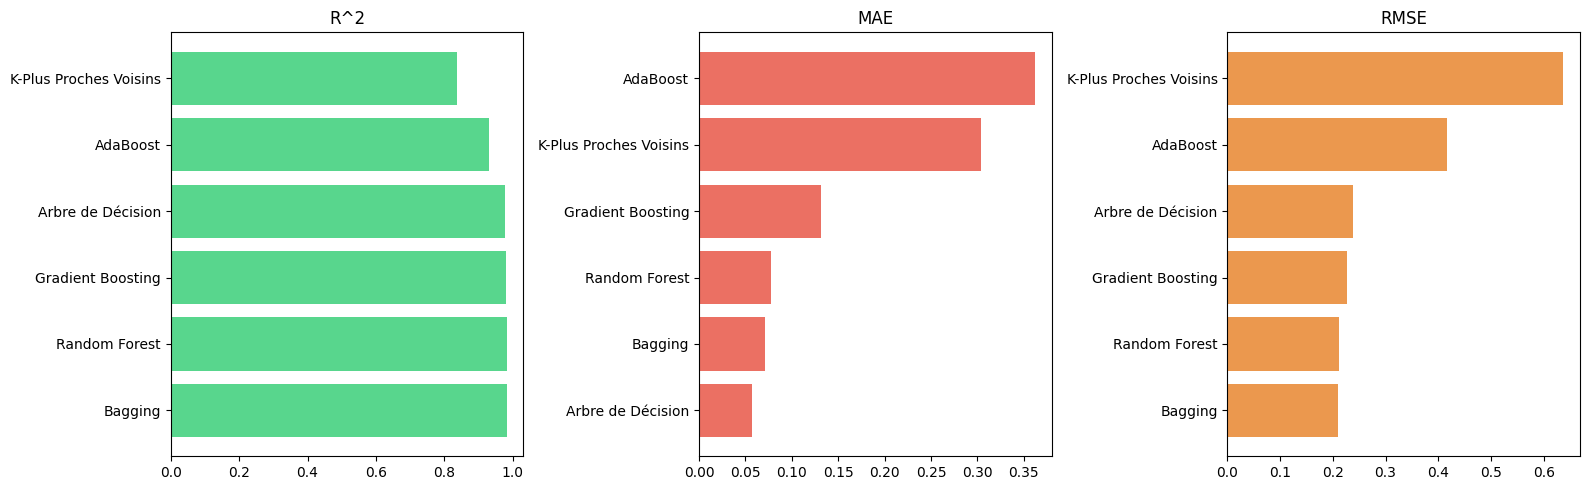

In [66]:
df_resultats = pd.DataFrame(resultats).T.sort_values('R^2', ascending=False)
display(df_resultats)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (metric, col) in zip(axes, [('R^2', '#2ecc71'), ('MAE', '#e74c3c'), ('RMSE', '#e67e22')]):
    vals = df_resultats[metric].sort_values(ascending=(metric != 'R^2'))
    ax.barh(vals.index, vals.values, color=col, alpha=0.8)
    ax.set_title(metric)

plt.tight_layout()
plt.show()

## 7. Validation croisée 5-fold

Le score obtenu sur un seul split train/test peut varier selon la façon dont les données ont été divisées — si par hasard les données de test sont particulièrement faciles ou difficiles à prédire, le score peut être trompeur.

La validation croisée à 5 blocs (5-fold cross-validation) permet de corriger cela. Le dataset est divisé en 5 sous-ensembles de taille égale. Le modèle est entraîné 5 fois : à chaque itération, 4 sous-ensembles servent à l'entraînement et le 5e sert de test. Le score final est la moyenne des 5 scores obtenus.

Cette méthode utilise l'ensemble des données à la fois pour l'entraînement et l'évaluation, ce qui donne une estimation plus fiable et moins sensible au hasard de la division initiale. L'écart-type des 5 scores indique la stabilité du modèle : un écart-type faible signifie que les performances sont cohérentes sur l'ensemble du dataset.

In [67]:
cv_resultats = {}
for nom, modele in modeles.items():
    scores = cross_val_score(modele, X, y, cv=5, scoring='r2', n_jobs=-1)
    cv_resultats[nom] = {'R^2 moyen': round(scores.mean(), 4), 'Écart-type': round(scores.std(), 4)}

pd.DataFrame(cv_resultats).T.sort_values('R^2 moyen', ascending=False)

,R^2 moyen,Écart-type
Random Forest,0.9578,0.0329
Bagging,0.9572,0.0339
Gradient Boosting,0.9559,0.0263
Arbre de Décision,0.9365,0.0388
AdaBoost,0.9178,0.0256
K-Plus Proches Voisins,0.5724,0.3123


## 8. Modèle principal : Random Forest explication détaillée

### Principe général

Le Random Forest (littéralement « forêt aléatoire ») est un algorithme dit d'**apprentissage par ensemble** (ensemble learning). L'idée de base est simple : plutôt que de se fier à un seul arbre de décision, on en construit un grand nombre, chacun entraîné dans des conditions légèrement différentes, puis on combine leurs prédictions.

### Fonctionnement détaillé

**1. Bootstrap sampling**  
Pour construire chaque arbre, on tire aléatoirement (avec remise) un sous-ensemble des données d'entraînement. Cela signifie que chaque arbre apprend sur un échantillon légèrement différent, certaines lignes apparaissent plusieurs fois, d'autres n'apparaissent pas. Cette technique s'appelle le bootstrap.

**2. Aléatoire sur les variables (feature randomness)**  
À chaque nœud de division d'un arbre, le modèle ne considère pas toutes les variables disponibles, mais seulement un sous-ensemble aléatoire. Par défaut en régression, ce sous-ensemble contient `n_features / 3` variables. Ce mécanisme réduit la corrélation entre les arbres et évite que tous convergent vers les mêmes divisions.

**3. Agrégation des prédictions**  
En régression, la prédiction finale est simplement la **moyenne** des prédictions de tous les arbres. Plus il y a d'arbres, plus cette moyenne est stable.


### Paramètres principaux

| Paramètre | Rôle | Valeur par défaut |
|---|---|---|
| `n_estimators` | Nombre d'arbres dans la forêt | 100 |
| `max_depth` | Profondeur maximale de chaque arbre (None = développement complet) | None |
| `max_features` | Nombre de variables testées à chaque division | `'sqrt'` en classification, `n_features/3` en régression |
| `min_samples_split` | Nombre minimum d'échantillons pour diviser un noeud | 2 |
| `random_state` | Graine aléatoire pour la reproductibilité | — |

### Avantages

Le Random Forest est résistant au surapprentissage (overfitting) : en moyennant de nombreux arbres qui ont chacun suivi différents aspects des données, les erreurs individuelles se compensent. Il est également robuste aux valeurs aberrantes, gère bien les variables de types différents, et calcule automatiquement l'importance des variables — ce qui est utile pour comprendre les résultats.

### Limites

Le modèle est moins interprétable qu'un seul arbre de décision, dont on peut suivre le chemin de décision pas à pas. Il est aussi plus lent à entraîner, et peut surapprendre si `max_depth` n'est pas limité sur un dataset de petite taille.

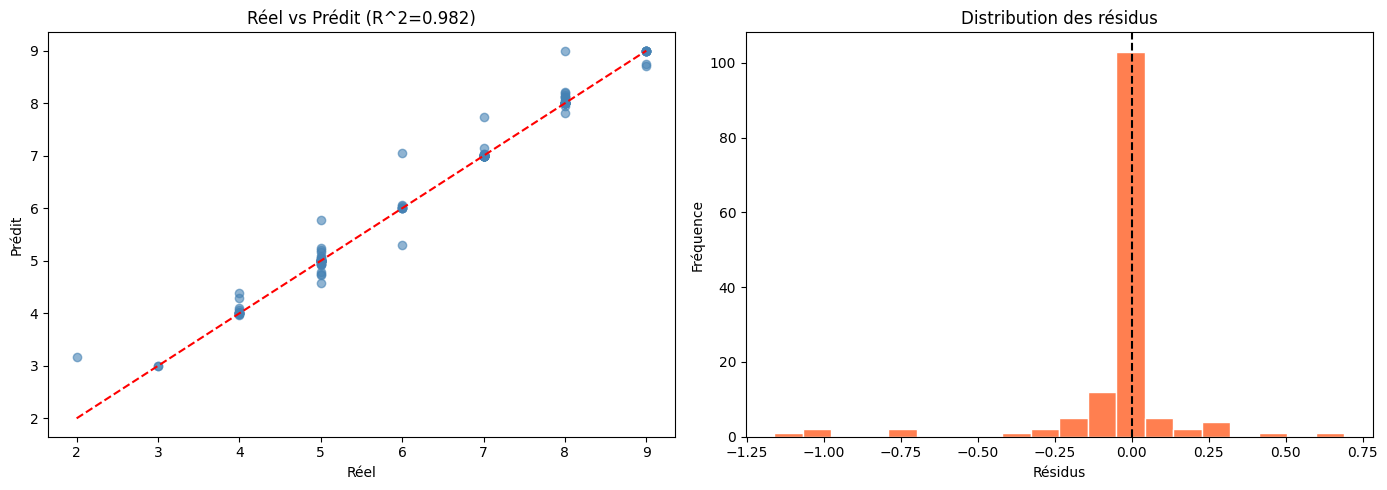

In [69]:
rf = modeles['Random Forest']
y_pred_rf = rf.predict(X_test)
residus = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_rf, alpha=0.6, color='steelblue')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[0].set(xlabel='Réel', ylabel='Prédit', title=f'Réel vs Prédit (R^2={resultats["Random Forest"]["R^2"]})')

axes[1].hist(residus, bins=20, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set(xlabel='Résidus', ylabel='Fréquence', title='Distribution des résidus')

plt.tight_layout()
plt.show()

## 9. Importance des variables (Random Forest)

L'un des avantages du Random Forest est de fournir automatiquement une mesure de l'importance de chaque variable dans les prédictions. Cette importance est calculée en mesurant, en moyenne sur tous les arbres, de combien chaque variable réduit l'impureté des nœuds lors des divisions (Mean Decrease in Impurity, MDI).

Une variable avec une importance élevée est une variable dont les valeurs influencent fortement la prédiction finale. Une variable avec une importance proche de zéro apporte peu d'information au modèle et pourrait être supprimée sans perte significative de performance.

La ligne en pointillé représente l'importance qu'aurait chaque variable si toutes contribuaient de manière égale.

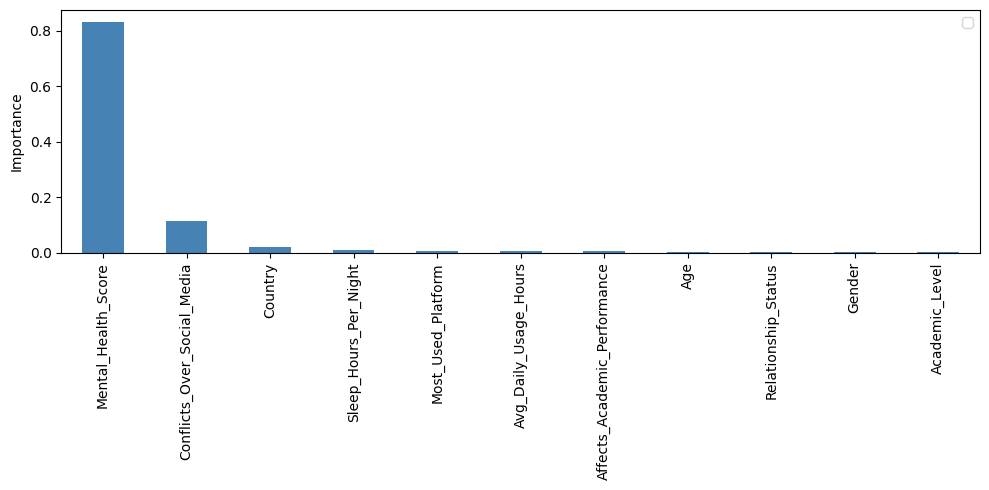

In [71]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

importances.plot(kind='bar', figsize=(10, 5), color='steelblue')
plt.ylabel('Importance')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Optimisation des hyperparamètres (GridSearchCV)

Les hyperparamètres sont les paramètres que l'on choisit avant d'entraîner le modèle — contrairement aux paramètres appris automatiquement pendant l'entraînement. Choisir de bons hyperparamètres peut améliorer sensiblement les performances.

`GridSearchCV` teste de manière exhaustive toutes les combinaisons possibles d'une grille de valeurs définie à l'avance. Pour chaque combinaison, il applique une validation croisée à 5 blocs et conserve les paramètres qui donnent le meilleur R^2 moyen.

Ici on teste différentes valeurs pour quatre paramètres : le nombre d'arbres (`n_estimators`), la profondeur maximale des arbres (`max_depth`), le nombre minimum d'échantillons pour diviser un nœud (`min_samples_split`), et le nombre de variables considérées à chaque division (`max_features`). La grille complète représente 3 × 4 × 3 × 3 = 108 combinaisons, chacune évaluée sur 5 folds.

In [72]:
param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features'     : ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid, cv=5, scoring='r2', n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

comparaison = pd.DataFrame({
    'Base'     : resultats['Random Forest'],
    'Optimisé' : {'R^2': round(r2_score(y_test, y_pred_best), 3),
                  'MAE': round(mean_absolute_error(y_test, y_pred_best), 3)}
})
comparaison['Δ'] = comparaison['Optimisé'] - comparaison['Base']
display(comparaison)

,Base,Optimisé,Δ
MAE,0.078,0.095,0.017
RMSE,0.211,NaN,NaN
R^2,0.982,0.985,0.003


## 11. Analyse des variables — problème de fuite de données

### Un R^2 de 0.98 : trop beau pour être vrai ?

Un R^2 de 0.98 sur un dataset de 705 observations est un résultat exceptionnellement élevé. Dans la plupart des problèmes réels, un tel score est le signe d'un problème de **fuite de données** (data leakage) : une variable explicative contient de l'information directement liée à la variable cible, au point que le modèle apprend une relation triviale plutôt qu'une vraie structure.

En regardant le graphique de corrélations, on remarque que `Mental_Health_Score` est de loin la variable la plus corrélée avec `Addicted_Score`. Il est probable que, dans ce dataset, le score de santé mentale ait été construit à partir du score d'addiction — ou inversement. Si c'est le cas, inclure cette variable revient à donner au modèle la réponse avant même qu'il ait besoin de chercher.

Pour vérifier cette hypothèse, on réentraîne le Random Forest en supprimant `Mental_Health_Score` et on compare les performances. Si le R² chute fortement, cela confirme que c'était cette variable qui portait presque toute la prédiction.

### Variables peu prédictives

D'autres variables sont peu corrélées avec `Addicted_Score` et contribuent peu aux prédictions : `Country` (haute cardinalité — trop de modalités pour que l'encodage soit efficace), `Most_Used_Platform` (le réseau social utilisé semble peu lié au niveau d'addiction), et `Relationship_Status`.

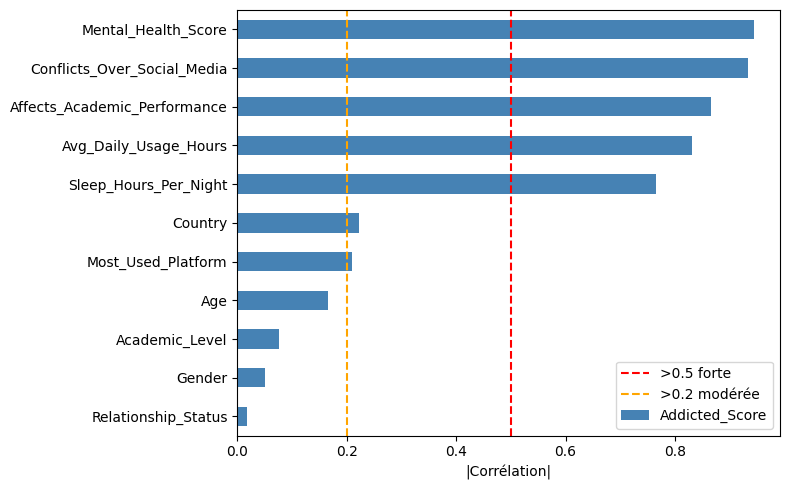

In [73]:
corr = df_ml.corr()['Addicted_Score'].drop('Addicted_Score').abs().sort_values()

corr.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.axvline(0.5, color='red', linestyle='--', label='>0.5 forte')
plt.axvline(0.2, color='orange', linestyle='--', label='>0.2 modérée')
plt.xlabel('|Corrélation|')
plt.legend()
plt.tight_layout()
plt.show()

,Avec Mental_Health_Score,Sans Mental_Health_Score
MAE,0.078,0.142
RMSE,0.211,NaN
R^2,0.982,0.971


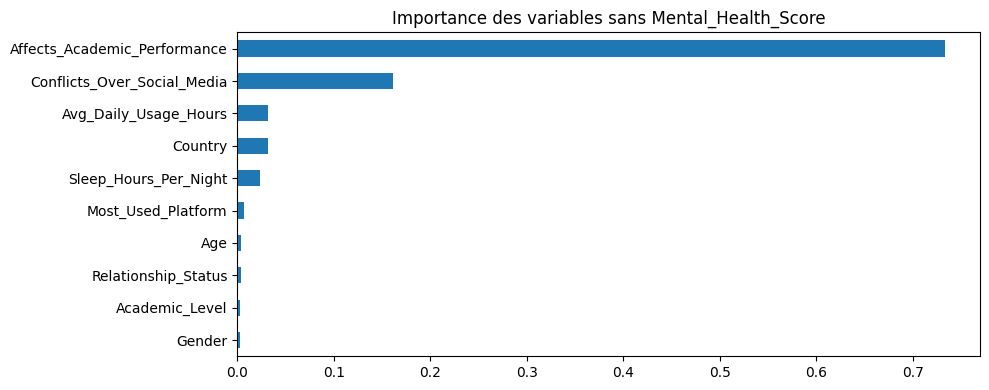

In [75]:
X_no_leak = X.drop(columns=['Mental_Health_Score'])
X_train_nl, X_test_nl, y_train_nl, y_test_nl = train_test_split(X_no_leak, y, test_size=0.2, random_state=42)

rf_no_leak = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_no_leak.fit(X_train_nl, y_train_nl)
y_pred_nl = rf_no_leak.predict(X_test_nl)

comparaison = pd.DataFrame({
    'Avec Mental_Health_Score' : resultats['Random Forest'],
    'Sans Mental_Health_Score' : {
        'R^2'  : round(r2_score(y_test_nl, y_pred_nl), 3),
        'MAE' : round(mean_absolute_error(y_test_nl, y_pred_nl), 3)
    }
})
display(comparaison)

pd.Series(rf_no_leak.feature_importances_, index=X_no_leak.columns)\
  .sort_values()\
  .plot(kind='barh', figsize=(10, 4), title='Importance des variables sans Mental_Health_Score')
plt.tight_layout()
plt.show()

## 12. Conclusion

### Résultats obtenus

Sur l'ensemble de test (20% des données, soit 141 étudiants), les six modèles produisent les résultats suivants :

| Modèle | MAE | RMSE | R^2 |
|---|---|---|---|
| Bagging | 0.071 | 0.209 | 0.982 |
| Random Forest | 0.078 | 0.211 | 0.982 |
| Gradient Boosting | 0.131 | 0.226 | 0.980 |
| Arbre de Décision | 0.057 | 0.238 | 0.977 |
| AdaBoost | 0.362 | 0.417 | 0.931 |
| K-Plus Proches Voisins | 0.304 | 0.637 | 0.838 |

En validation croisée (5-fold), le Random Forest obtient un R^2 moyen de 0.9578 avec un écart-type de 0.033, ce qui confirme la stabilité de ses performances sur l'ensemble du dataset.

### Interprétation

Les scores R^2 très élevés (entre 0.97 et 0.98) s'expliquent principalement par la présence de `Mental_Health_Score`, qui est très fortement corrélée avec `Addicted_Score`. En supprimant cette variable, les performances chutent de manière significative, ce qui confirme l'existence d'une fuite de données dans ce dataset.

Les variables réellement prédictives, une fois `Mental_Health_Score` retirée, sont `Avg_Daily_Usage_Hours`, `Conflicts_Over_Social_Media` et `Sleep_Hours_Per_Night` — ce qui est plus cohérent avec la réalité.

Les variables `Country`, `Most_Used_Platform` et `Relationship_Status` contribuent peu aux prédictions. La variable `Country` pose un problème particulier : avec plus de 100 pays encodés comme des entiers séquentiels, le modèle peut difficilement en tirer une information utile.

Le modèle K-Plus Proches Voisins obtient des résultats nettement inférieurs aux autres (R^2 = 0.84 en test, écart-type de 0.31 en CV). Sa grande instabilité indique qu'il ne généralise pas bien sur ce dataset, probablement à cause de la forte dimension de l'espace des features.